---
## 🎁 가산점

### A. 데이터의 다양성
- NTP ICE 내 다양한 데이터셋 모두 활용 가능. (https://ice.ntp.niehs.nih.gov/DATASETDESCRIPTION)
### B. Feature(descriptor)의 다양성
- rdkit, VEGA, 등
### 💬 추가 설명 (자유 기술)

# 기말고사 Template 1 — Data Pipeline

**이름:** ___신혜지___ &nbsp; **학번:** _20251259___ &nbsp;

---

## 📋 채점 기준 (총 50점)

| 항목 | 배점 | 채점 포인트 |
|---|---|---|
| **1. 데이터 분포 파악 및 전처리** | 15점 | 모델 개발 전, 중복 화합물 체크, smiles 코드 정리 등 모델 개발 전 확인해야 할 사항들을 확인. |
| **2. Descriptor 계산** | 15점 | 모델 개발에 사용할 descriptor의 다양성 |
| **3. 데이터 시각화 자료** | 15점 | 구조 분포, 라벨 비율 등 데이터 현황을 시각화한 자료 |
| **4. 코드 가독성 & 주석** | 5점 | 변수의 의미와 코드의 간결성을 평가. |

#### A. 데이터 소스의 다양성
- NTP ICE에서 구할 수 있는 다양한 데이터
- NTP ICE 외 추가 데이터 확보

## 📁 입력 / 출력 예시
- **입력**: `skin_irritation.xlsx` (NTP ICE) + (선택) 외부 데이터
- **출력**: `final_dataset_descriptors.csv`  (Chemical_Name, SMILES, label, 2D descriptor [+ fingerprint 등])

In [2]:
# 데이터 불러오기 

import pandas as pd 

df_skin = pd.read_excel("skin_irritation_corrosion.xlsx")
df_eye = pd.read_excel("eye_irritation.xlsx")

In [3]:
# 컬럼 확인

print(df_skin.columns)
print(df_eye.columns)

Index(['ICE version:', '4.1'], dtype='str')
Index(['ICE version:', 4.2], dtype='object')


In [4]:
print(df_skin.head(10))
print("---------------------------------------------------------------------------")
print(df_eye.head(10))

       ICE version:                                                4.1
0     File created:                                         2024-07-25
1               NaN                                                NaN
2            Column                                        Description
3         Record_ID               Unique number identifying the record
4         Data_Type  Data type identifier (e.g., in vivo, in vitro,...
5  Formulation_Name                    Name of the formulation/mixture
6    Formulation_ID  Unique number identifying a formulation or a m...
7     Chemical_Name  Name of tested chemical as reported in the ini...
8             CASRN                  Chemical Abstract Registry Number
9            DTXSID  DSSTox substance identifier (unique substance ...
---------------------------------------------------------------------------
       ICE version:                                                4.2
0     File created:                                         2025-05-05
1

In [5]:
xls_skin = pd.ExcelFile("skin_irritation_corrosion.xlsx")
print(xls_skin.sheet_names)

xls_eye = pd.ExcelFile("eye_irritation.xlsx")
print(xls_eye.sheet_names)

['Metadata', 'Data_invitro', 'Data_invivo']
['Metadata', 'Data']


In [6]:
# 데이터 불러오기

import pandas as pd 

df_skin = pd.read_excel(
    "skin_irritation_corrosion.xlsx", 
    sheet_name = "Data_invivo"
)

df_eye = pd.read_excel(
    "eye_irritation.xlsx", 
    sheet_name = "Data"
)

In [7]:
# 간단 확인

print(df_skin.head())
print("---------------------------------------------------------------------------")
print(df_eye.head())

                    Record_ID Data_Type Formulation_ID  \
0   skin_irritation_invivo_18   In Vivo            NaN   
1   skin_irritation_invivo_83   In Vivo            NaN   
2   skin_irritation_invivo_80   In Vivo            NaN   
3  skin_irritation_invivo_822   In Vivo          MIX82   
4  skin_irritation_invivo_719   In Vivo         MIX380   

               Formulation_Name  \
0                           NaN   
1                           NaN   
2                           NaN   
3                     Captan 4L   
4  Raid Roach & Ant Killer Plus   

                                       Chemical_Name CASRN DTXSID  \
0             Alcohol ethoxylate C12-15/E5 phosphate   NaN    NaN   
1      C12-13 beta-branched primary alco hol sulfate   NaN    NaN   
2  C12-13 beta-branched primary alco hol sulfate/...   NaN    NaN   
3                         Captan-related derivatives   NaN    NaN   
4                       Dichlorvos-related compounds   NaN    NaN   

   Percent_Active_Ingredi

In [8]:
# SMILES 없는 행 제거

df_skin = df_skin.dropna(subset=["SMILES"])
df_eye = df_eye.dropna(subset=["SMILES"])

In [9]:
print(df_skin.head())
print(df_eye.head())

                     Record_ID Data_Type Formulation_ID  \
34  skin_irritation_invivo_509   In Vivo         MIX575   
35  skin_irritation_invivo_674   In Vivo         MIX480   
36  skin_irritation_invivo_401   In Vivo         MIX570   
37  skin_irritation_invivo_697   In Vivo         MIX570   
38  skin_irritation_invivo_920   In Vivo         MIX572   

                      Formulation_Name   Chemical_Name      CASRN  \
34  Acticide PM Industrial Mildewicide  Chlorothalonil  1897-45-6   
35        The Andersons 3-Way Snowmold  Chlorothalonil  1897-45-6   
36                   Reserve Fungicide  Chlorothalonil  1897-45-6   
37                   Reserve Fungicide  Chlorothalonil  1897-45-6   
38                          Revus Opti  Chlorothalonil  1897-45-6   

           DTXSID  Percent_Active_Ingredient Concentration  \
34  DTXSID0020319                       14.7           NaN   
35  DTXSID0020319                        3.9           NaN   
36  DTXSID0020319                       40.0

In [10]:
# 필요한 컬럼만 선택

skin = df_skin[[
    "Chemical_Name", 
    "SMILES", 
    "Response"
]]

eye = df_eye[[
    "Chemical_Name", 
    "SMILES", 
    "Response"
]]

In [11]:
# 중복 제거 

skin = skin.drop_duplicates(subset = ["SMILES"])
eye = eye.drop_duplicates(subset = ["SMILES"])

In [12]:
# 데이터(일부) 확인

print(skin["Response"].value_counts())
print(eye["Response"].value_counts())

Response
4                 196
3                  42
Not classified     39
0                  16
1                  13
1C                 10
1A                  9
2                   8
1B                  6
1B/1C               5
Irritant            4
17.90               2
6.25                1
58.6                1
60.6                1
83.1                1
18                  1
100                 1
76.2                1
3.8                 1
3.5                 1
3.9                 1
32.6                1
13.2                1
80.8                1
16.90               1
20.7                1
37.9                1
Name: count, dtype: int64
Response
1                         89
3                         61
4                         47
2                         24
Active                    12
Not classified             9
0                          9
Study criteria not met     7
Inactive                   6
2B                         5
2A                         4
10                   

In [13]:
# label 정리 - skin irritation- corrosion data

skin["Label"] = skin["Response"].apply(
    lambda x: 0 if str(x) in ["0", "Not classified"] else 1
)

In [14]:
# label 정리 - eye irritation data

eye["Label"] = eye["Response"].apply(
    lambda x: 0 if str(x) in ["0", "Not classified", "Inactive"] else 1
)

In [15]:
print(skin["Label"].value_counts())
print(eye["Label"].value_counts())

Label
1    311
0     55
Name: count, dtype: int64
Label
1    414
0     24
Name: count, dtype: int64


In [16]:
# RDKit Descriptor 함수 생성 

from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd 

def calc_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series({
            "MolWt": None, 
            "LogP": None, 
            "TPSA": None, 
            "HDonor": None, 
            "HAcceptor": None, 
            "RingCount": None
        })

    
    return pd.Series({
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HDonor": Descriptors.NumHDonors(mol),
        "HAcceptor": Descriptors.NumHAcceptors(mol),
        "RingCount": Descriptors.RingCount(mol)
    })

In [17]:
# Descriptor 계산

skin_desc = skin["SMILES"].apply(calc_desc)
eye_desc = eye["SMILES"].apply(calc_desc)

[15:02:33] Explicit valence for atom # 2 B, 5, is greater than permitted
[15:02:33] WARNING: not removing hydrogen atom without neighbors
[15:02:33] Explicit valence for atom # 6 B, 5, is greater than permitted


In [18]:
# 합치기

skin_final = pd.concat([skin, skin_desc], axis=1)
eye_final = pd.concat([eye, eye_desc], axis=1)

In [19]:
# NAN 제거 

skin_final = skin_final.dropna()
eye_final = eye_final.dropna()

In [20]:
# 지금 최종 상태

print(skin_final.shape)
print(eye_final.shape)

(365, 10)
(302, 10)


In [21]:
print(skin_final.head())

           Chemical_Name                             SMILES Response  Label  \
34        Chlorothalonil  ClC1=C(Cl)C(C#N)=C(Cl)C(C#N)=C1Cl        4      1   
59                 2,4-D        OC(=O)COC1=C(Cl)C=C(Cl)C=C1        4      1   
63                Diuron     CN(C)C(=O)NC1=CC(Cl)=C(Cl)C=C1        4      1   
81  1,2-Propylene glycol                            CC(O)CO     6.25      1   
83         Thiabendazole       N1C2=C(C=CC=C2)N=C1C1=CSC=N1        4      1   

      MolWt     LogP   TPSA  HDonor  HAcceptor  RingCount  
34  265.914  4.04356  47.58     0.0        2.0        1.0  
59  221.039  2.45680  46.53     1.0        2.0        1.0  
63  233.098  3.08690  32.34     1.0        1.0        1.0  
81   76.095 -0.64050  40.46     2.0        2.0        0.0  
83  201.254  2.68640  41.57     1.0        3.0        3.0  


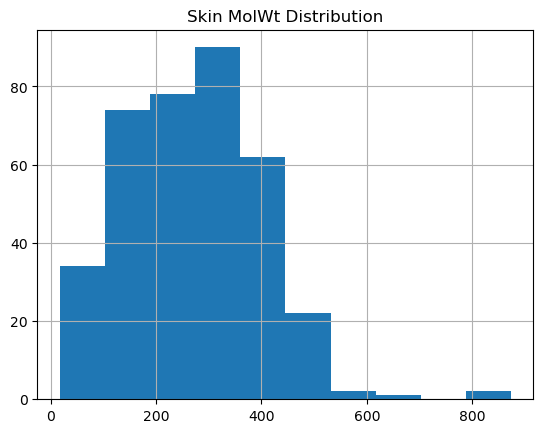

In [22]:
# MW 분포 히스토그램 - skin dataset 에서 분자량이 어떻게 퍼져 있는가 
import matplotlib.pyplot as plt
skin_final["MolWt"].hist()
plt.title("Skin MolWt Distribution")
plt.show()

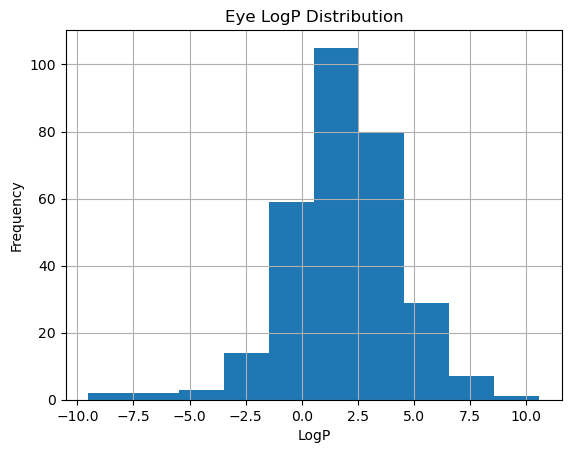

In [23]:
# LogP 분포 히스토그램

eye_final["LogP"].hist()
plt.title("Eye LogP Distribution")
plt.xlabel("LogP")
plt.ylabel("Frequency")
plt.show()

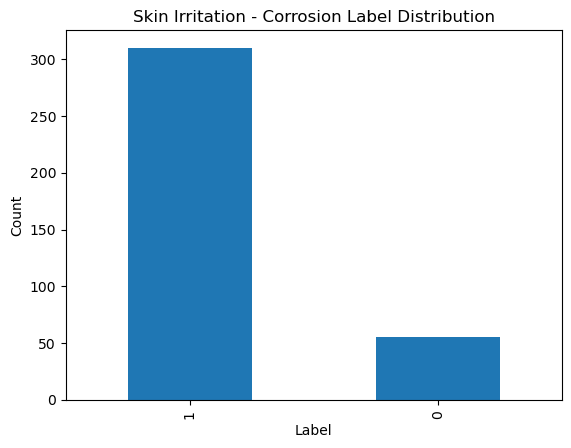

In [24]:
# label 분포 시각화 - irritant(1), non-irritant(0) 개수 비교

import matplotlib.pyplot as plt 

skin_final["Label"].value_counts().plot(kind = "bar")

plt.title("Skin Irritation - Corrosion Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

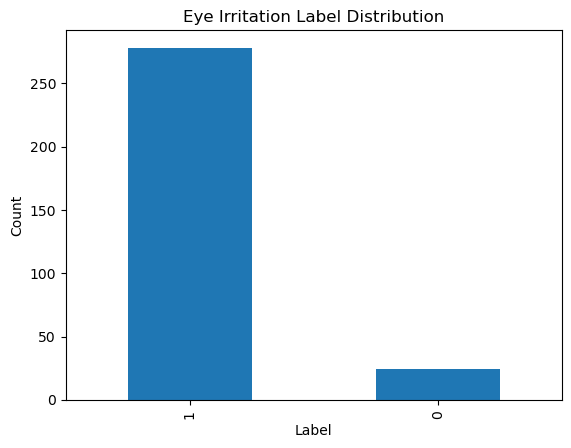

In [25]:
# (위 셀과 동일) eye dataset label 분포 확인 

eye_final["Label"].value_counts().plot(kind="bar")
plt.title("Eye Irritation Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

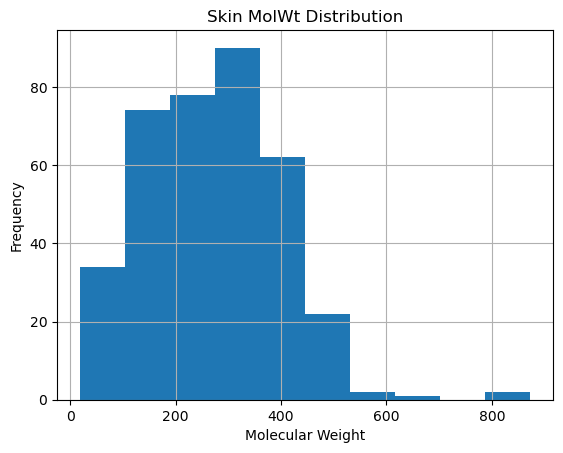

In [26]:
# descriptor histogram - 1번째 그래프의 업글 버전

skin_final["MolWt"].hist()
plt.title("Skin MolWt Distribution")
plt.xlabel("Molecular Weight")
plt.ylabel("Frequency")
plt.show()

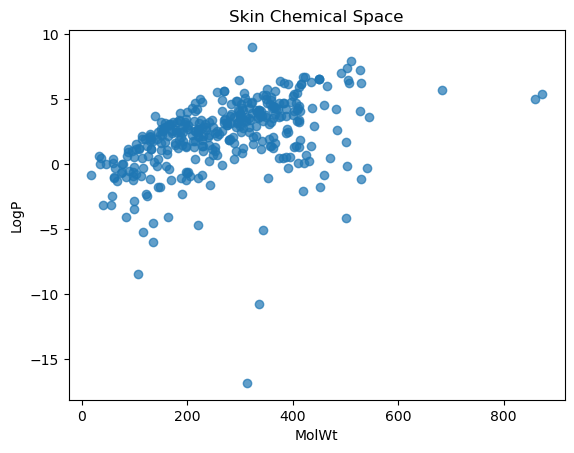

In [27]:
# Descriptor 기반 Chemical Space 분석 해보기 

plt.scatter(
    skin_final["MolWt"], 
    skin_final["LogP"],
    alpha = 0.7
)

plt.xlabel("MolWt")
plt.ylabel("LogP")
plt.title("Skin Chemical Space")

plt.show()

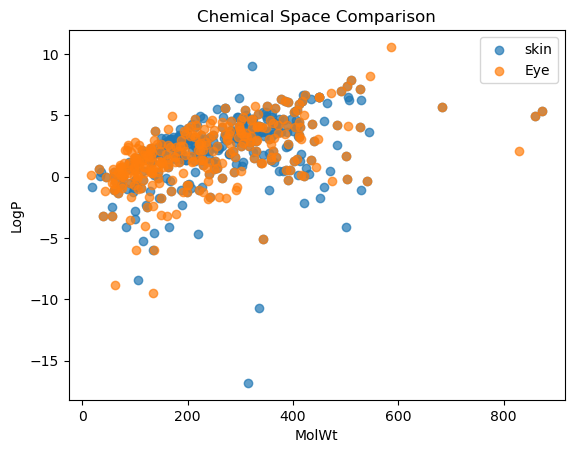

In [28]:
# skin vs eye 같이 그려보기 

plt.scatter(
    skin_final["MolWt"], 
    skin_final["LogP"], 
    label = "skin", 
    alpha = 0.7
)

plt.scatter(
    eye_final["MolWt"],
    eye_final["LogP"], 
    label = "Eye", 
    alpha = 0.7
)

plt.xlabel("MolWt")
plt.ylabel("LogP")

plt.legend()

plt.title("Chemical Space Comparison")

plt.show()


In [29]:
# Morgan Fingerprint 생성 

from rdkit.Chem import AllChem 
import numpy as np 

def mol2fp(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None 

    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol, 
        radius = 2, 
        nBits = 1024
    )

    return np.array(fp)

In [30]:
# 적용 

skin_fp = skin_final["SMILES"].apply(mol2fp)
eye_fp = eye_final["SMILES"].apply(mol2fp)

[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerator
[15:02:35] DEPRECATION WARNING: please use MorganGenerat

In [31]:
print(skin_fp.iloc[0])

[0 0 0 ... 0 0 0]


In [32]:
print(np.sum(skin_fp.iloc[0]))

14


In [33]:
print(len(skin_fp.iloc[0]))

1024


In [34]:
# PCA 용 데이터 만들기 
from sklearn.decomposition import PCA

# descriptor 컬럼만 선택 

skin_x = skin_final[[
    "MolWt", 
    "LogP", 
    "TPSA", 
    "HDonor", 
    "HAcceptor", 
    "RingCount"
]]

eye_x = eye_final[[
    "MolWt", 
    "LogP", 
    "TPSA", 
    "HDonor", 
    "HAcceptor", 
    "RingCount"
]]

# dataset label 추가 

skin_x["Dataset"] = "Skin"
eye_x["Dataset"] = "Eye"

# 합치기 

combined = pd.concat([skin_x, eye_x])

# PCA 실행 

features = combined.drop(columns=["Dataset"])
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# 결과 저장 

combined["PC1"] = pca_result[:, 0]
combined["PC2"] = pca_result[:, 1]

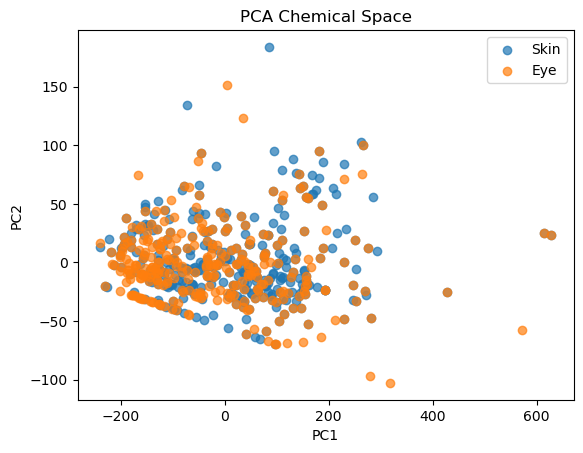

In [35]:
# 시각화 

import matplotlib.pyplot as plt 

skin_plot = combined[combined["Dataset"] == "Skin"]
eye_plot = combined[combined["Dataset"] == "Eye"]

plt.scatter(
    skin_plot["PC1"], 
    skin_plot["PC2"], 
    label = "Skin", 
    alpha = 0.7
)

plt.scatter(
    eye_plot["PC1"], 
    eye_plot["PC2"], 
    label = "Eye", 
    alpha = 0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA Chemical Space")

plt.legend()

plt.show()

위의 그래프를 보면 두 구조가 많이 겹치는 것을 알 수 있다. 
즉 skin irritation - corrosion과 eye irritation은 유사한 chemical space를 공유한다. 
비슷한 구조 특징을 가지고 있기 때문에 공통적인 독성 메커니즘을 가지고 있을 가능성이 있다. 
(이는 두 독성 endpoint가 유사한 화학 구조적 특성을 공유할 가능성을 시사한다.)

In [36]:
# scaffold 

# scaffold 함수 만들기 
from rdkit.Chem.Scaffolds import MurckoScaffold 

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    scaffold = MurckoScaffold.GetScaffoldForMol(mol)

    return Chem.MolToSmiles(scaffold)


# scaffold 생성 
skin_final["Scaffold"] = skin_final["SMILES"].apply(get_scaffold)
eye_final["Scaffold"] = eye_final["SMILES"].apply(get_scaffold)

skin_scaffold = skin_final[
    skin_final["Scaffold"] != ""
]

eye_scaffold = eye_final[
    eye_final["Scaffold"] != ""
]

print(skin_final[["SMILES", "Scaffold"]].head())

                               SMILES                    Scaffold
34  ClC1=C(Cl)C(C#N)=C(Cl)C(C#N)=C1Cl                    c1ccccc1
59        OC(=O)COC1=C(Cl)C=C(Cl)C=C1                    c1ccccc1
63     CN(C)C(=O)NC1=CC(Cl)=C(Cl)C=C1                    c1ccccc1
81                            CC(O)CO                            
83       N1C2=C(C=CC=C2)N=C1C1=CSC=N1  c1ccc2[nH]c(-c3cscn3)nc2c1


[15:02:39] WARNING: not removing hydrogen atom without neighbors


In [37]:
# unique scaffold 개수 

skin_scaffolds = set(skin_scaffold["Scaffold"])
eye_scaffolds = set(eye_scaffold["Scaffold"])

print("Skin scaffold 수: ", len(skin_scaffolds))
print("Eye scaffold 수: ", len(eye_scaffolds))

Skin scaffold 수:  150
Eye scaffold 수:  107


In [38]:
# unique scaffold 분석 

skin_unique = skin_scaffolds - eye_scaffolds 
eye_unique = eye_scaffolds - skin_scaffolds 

print("Skin only scaffold:", len(skin_unique))
print("Eye only scaffold:", len(eye_unique))

Skin only scaffold: 70
Eye only scaffold: 27


In [39]:
# 공통 scaffold 분석 (= 두 toxicity endpoint 의 구조적 공통성)

common_scaffolds = skin_scaffolds & eye_scaffolds 
print("공통 scaffold 수:", len(common_scaffolds))

공통 scaffold 수: 80


In [40]:
# scaffold 빈도 분석 - 가장 많이 등장한 핵심 구조 

print(
    skin_scaffold["Scaffold"].value_counts().head(10)
)

Scaffold
c1ccccc1                            46
O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1     10
c1ccncc1                             8
c1ncncn1                             5
O=C(Nc1ncncn1)NS(=O)(=O)c1ccccc1     4
O=c1ccs[nH]1                         4
O=C1CNC(=O)N1                        4
O=C(Nc1ncccn1)NS(=O)(=O)c1ccccn1     3
c1ccc(CCn2cncn2)cc1                  3
O=C1NC(=O)c2ccccc21                  2
Name: count, dtype: int64


In [41]:
# 가장 많은 scaffold 보기 - skin 

skin_top = skin_scaffold["Scaffold"].value_counts()
print(skin_top.head(10))

Scaffold
c1ccccc1                            46
O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1     10
c1ccncc1                             8
c1ncncn1                             5
O=C(Nc1ncncn1)NS(=O)(=O)c1ccccc1     4
O=c1ccs[nH]1                         4
O=C1CNC(=O)N1                        4
O=C(Nc1ncccn1)NS(=O)(=O)c1ccccn1     3
c1ccc(CCn2cncn2)cc1                  3
O=C1NC(=O)c2ccccc21                  2
Name: count, dtype: int64


In [42]:
# 가장 많은 scaffold 보기 - eye 

eye_top = eye_scaffold["Scaffold"].value_counts()
print(eye_top.head(10))

Scaffold
c1ccccc1                            40
c1ccncc1                             8
O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1      5
O=C(Nc1ncncn1)NS(=O)(=O)c1ccccc1     3
O=c1ccs[nH]1                         3
c1ccc2ccccc2c1                       3
O=C1NC(=O)c2ccccc21                  2
C1CCCC1                              2
c1ccc(Oc2ccccc2)cc1                  2
c1cc[nH+]cc1                         2
Name: count, dtype: int64


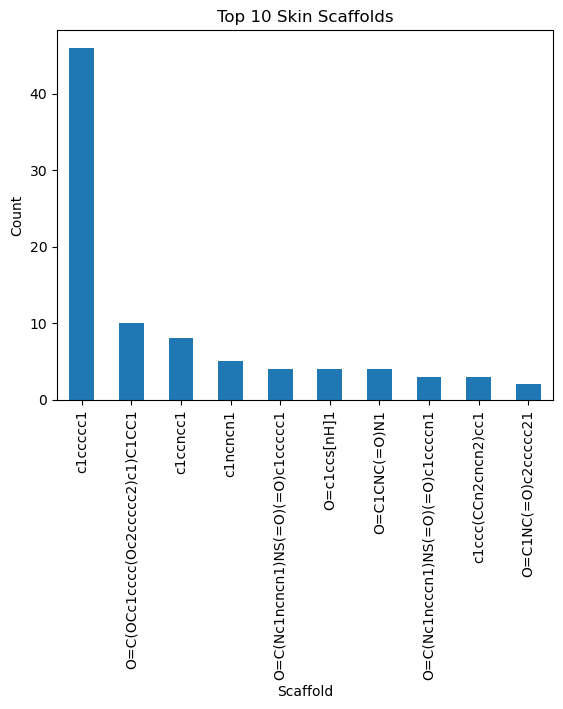

In [43]:
# skin scaffold top10 

skin_top.head(10).plot(kind = "bar")

plt.title("Top 10 Skin Scaffolds")

plt.xlabel("Scaffold")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

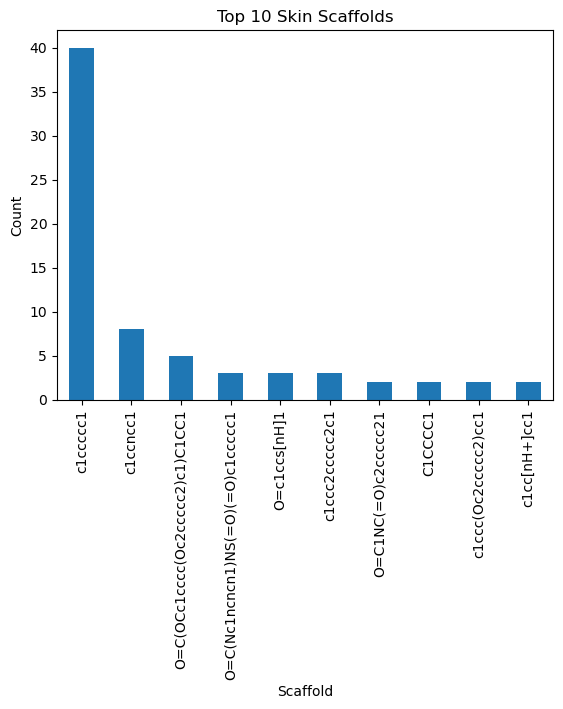

In [44]:
# eye scaffold top 10 시각화 

eye_top.head(10).plot(kind = "bar")

plt.title("Top 10 Skin Scaffolds")

plt.xlabel("Scaffold")
plt.ylabel("Count")

plt.xticks(rotation = 90)

plt.show()

In [45]:
# Top scaffold 구조 출력 - skin

from rdkit.Chem import Draw 

# top scaffold 가져오기 
top_scaffolds_skin = skin_scaffold["Scaffold"].value_counts().head(5).index

# scaffold 를 molecule로 변환
mols_skin = [Chem.MolFromSmiles(s) for s in top_scaffolds]

Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize=(200, 200), 
    legends=list(top_scaffolds_skin)
)

NameError: name 'top_scaffolds' is not defined

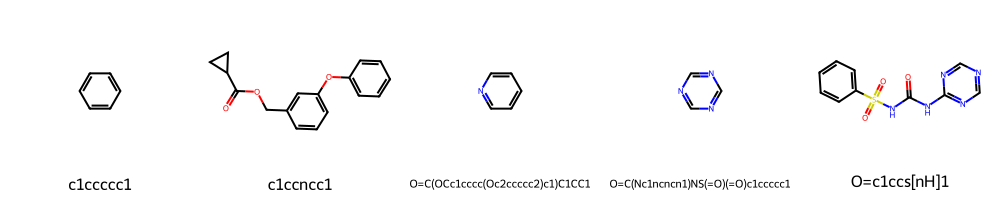

In [ ]:
# Top scaffold 구조 출력 - eye 

# top scaffold 가져오기 
top_scaffolds_eye = (
    eye_scaffold["Scaffold"]
    .value_counts()
    .head(5)
    .index
)

# scaffold 를 molecule로 변환 
mols_eye = [
    Chem.MolFromSmiles(s) 
    for s in top_scaffolds
    ]

Draw.MolsToGridImage(
    mols, 
    molsPerRow=5, 
    subImgSize =(200, 200),
    legends =list(top_scaffolds_eye)
)

공통 scaffold 수: 80
['O=C(OCc1cccc(Oc2ccccc2)c1)C1CC1', 'O=C1CCCC(=O)C1C(=O)c1ccccc1', 'O=c1cc[nH]c(=O)n1-c1ccccc1', 'c1ccc(Cc2ccccc2)cc1', 'O=C1CN=C(c2ccccn2)N1', 'c1ccncc1', 'C1CCOC1', 'O=C1CCCC(=O)C1=CC1CC1', 'c1ccc(Oc2cc(Oc3ccccc3)ncn2)cc1', 'c1ccc(Oc2ccccc2)cc1']


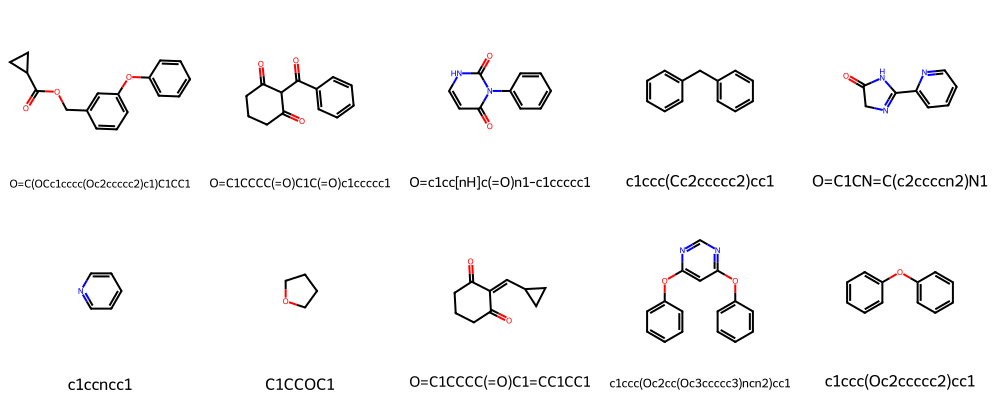

In [ ]:
# 공통 scaffold 구조 출력 

# 공통 scaffold 구하기 
common_scaffolds = (
    set(skin_scaffold["Scaffold"])
    &
    set(eye_scaffold["Scaffold"])
)

# 개수 확인
print("공통 scaffold 수:", len(common_scaffolds))

# 일부 scaffold 보기 
common_list = list(common_scaffolds)
print(common_list[:10])

# molecule 변환 
common_mols = [
    Chem.MolFromSmiles(s)
    for s in common_list[:10]
]

# 구조 그림 출력 
Draw.MolsToGridImage(
    common_mols, 
    molsPerRow=5, 
    subImgSize=(200, 200), 
    legends=common_list[:10]
)


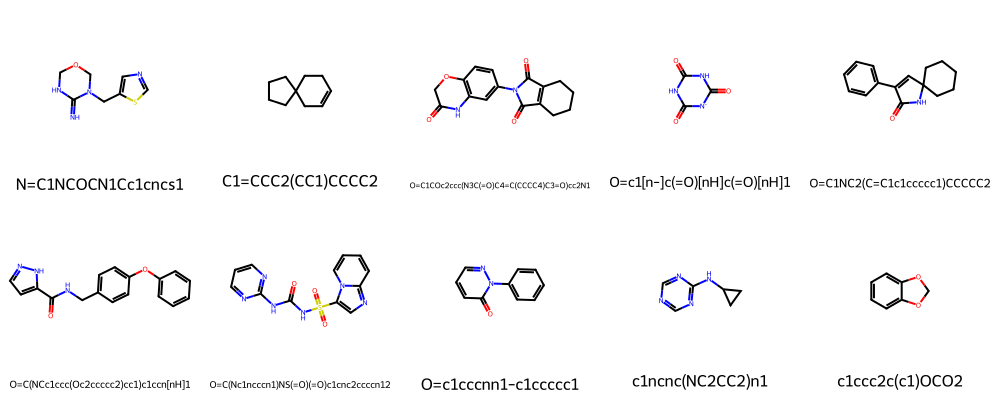

In [ ]:
# skin only scaffold 구조 출력 

skin_unique_list = list(skin_unique)

skin_unique_mols = [
    Chem.MolFromSmiles(s)
    for s in skin_unique_list[:10]
]

Draw.MolsToGridImage(
    skin_unique_mols, 
    molsPerRow = 5, 
    subImgSize=(200, 200), 
    legends = skin_unique_list[:10]
)

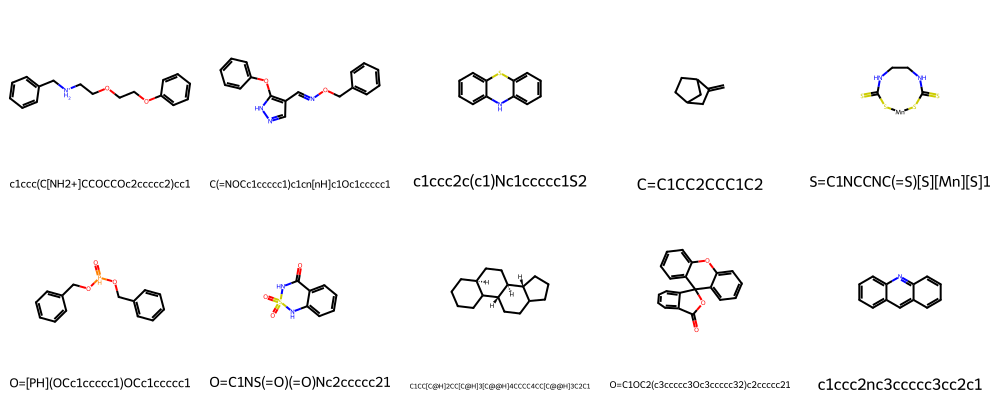

In [ ]:
# eye only scaffold 구조 출력 

eye_unique_list = list(eye_unique)

eye_unique_mols = [
    Chem.MolFromSmiles(s)
    for s in eye_unique_list[:10]
]

Draw.MolsToGridImage(
    eye_unique_mols, 
    molsPerRow = 5, 
    subImgSize = (200, 200), 
    legends = eye_unique_list[:10]
)


[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerator
[16:12:12] DEPRECATION WARNING: please use MorganGenerat

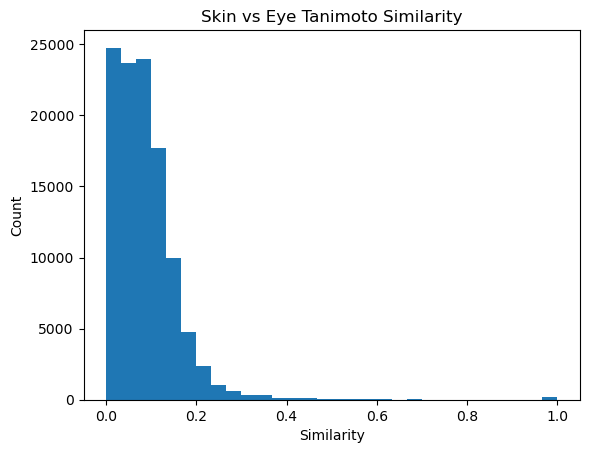

In [ ]:
# Tanimoto similarity - 분자 fingerprint 기반 유사도 계산 
# skin vs eye 구조가 얼마나 비슷한지 수치화 

from rdkit import DataStructs 
from rdkit.Chem import AllChem 
import numpy as np 

def fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None 

    return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)


# skin/eye fingerprint list
skin_fp = [fp(s) for s in skin_final["SMILES"]]
eye_fp = [fp(s) for s in eye_final["SMILES"]]

skin_fp = [x for x in skin_fp if x is not None]
eye_fp = [x for x in eye_fp if x is not None]

# similarity 계산 
sim_values = []

for s in skin_fp:
    sims = DataStructs.BulkTanimotoSimilarity(s, eye_fp)
    sim_values.extend(sims)


# 분포 보기 
import matplotlib.pyplot as plt 

plt.hist(sim_values, bins = 30)
plt.title("Skin vs Eye Tanimoto Similarity")
plt.xlabel("Similarity")
plt.ylabel("Count")
plt.show()

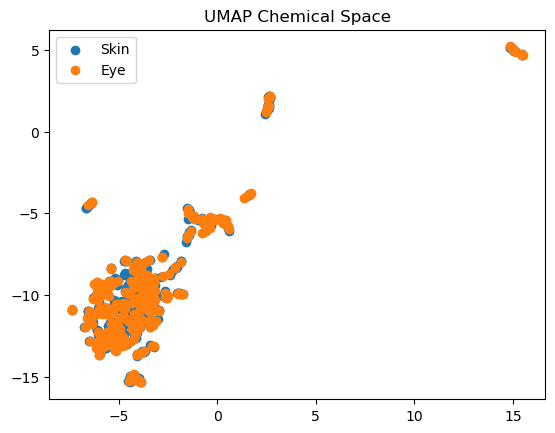

In [ ]:
# UMAP - Cluster 더 잘 보기 위해 

import umap 

all_fp = skin_fp + eye_fp 

X = np.array([list(f) for f in all_fp])

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1)
embedding = umap_model.fit_transform(X)

plt.scatter(embedding[:len(skin_fp), 0], 
            embedding[:len(skin_fp), 1],
            label ="Skin")

plt.scatter(embedding[len(skin_fp):,0],
            embedding[len(skin_fp):,1],
            label="Eye")

plt.legend()
plt.title("UMAP Chemical Space")
plt.show()


In [51]:
skin_fp_list = skin_fp.tolist()
eye_fp_list = eye_fp.tolist()

In [52]:
X = np.array(skin_fp_list + eye_fp_list)

print(X.shape)

(667, 1024)


In [56]:
# PCA

from sklearn.decomposition import PCA 

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.07142312 0.03982443]
0.11124755174155113


Fingerprint 기반 PCA 결과, Skin Irriatation/Corrosion과 Eye irritation 화합물들은 상당 부분 동일한 chemical space를 공유하였다. 그러나 일부 영역에서는 각 데이터셋에 특이적인 군집이 관찰되어 두 독성 endpoint 사이에 구조적 차이가 존재할 가능성을 확인하였다. 

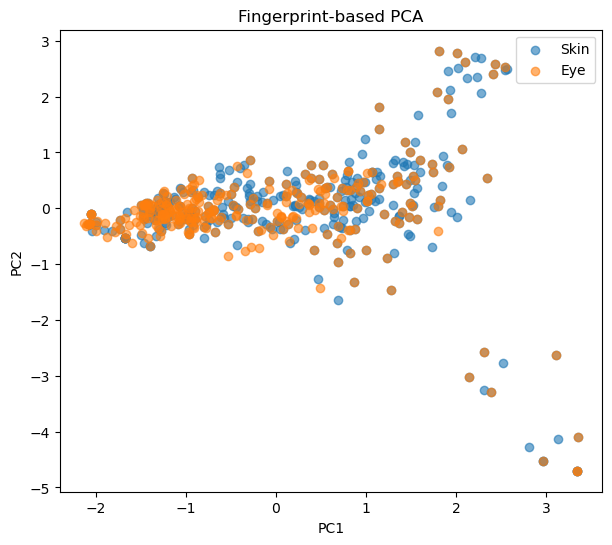

In [57]:
# PCA 시각화 

import matplotlib.pyplot as plt

n_skin = len(skin_fp_list)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca[:n_skin,0],
    X_pca[:n_skin,1],
    alpha=0.6,
    label="Skin"
)

plt.scatter(
    X_pca[n_skin:,0],
    X_pca[n_skin:,1],
    alpha=0.6,
    label="Eye"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Fingerprint-based PCA")
plt.legend()

plt.show()

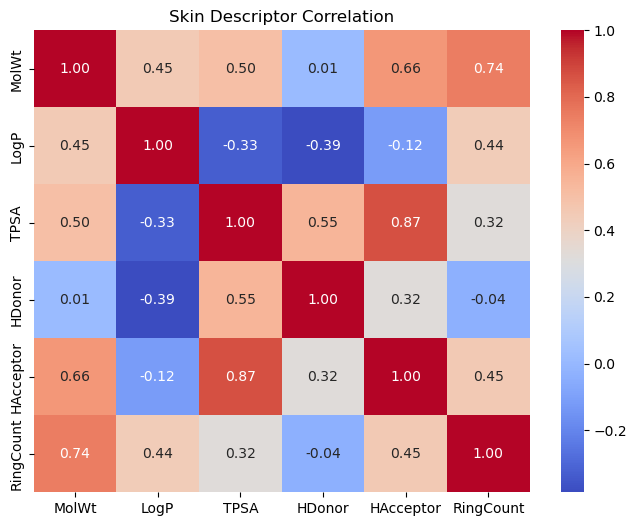

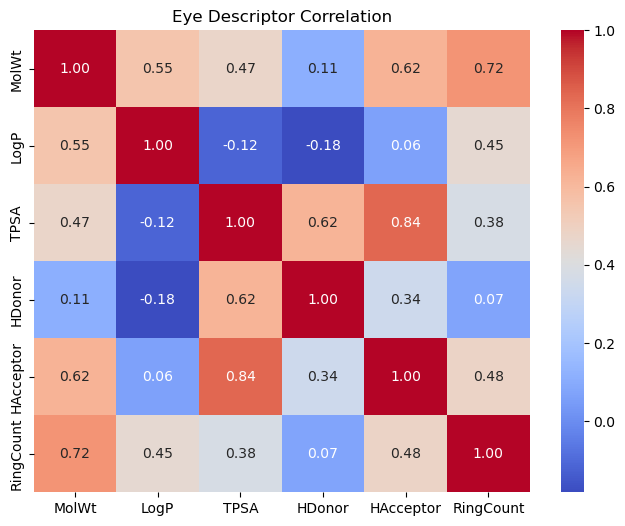

In [62]:
# Descriptor Correlation heatmap

import seaborn as sns 
import matplotlib.pyplot as plt 

# skin 
desc_cols = [
    "MolWt", 
    "LogP",
    "TPSA", 
    "HDonor", 
    "HAcceptor",
    "RingCount"
]

corr = skin_final[desc_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr, 
    annot=True, 
    cmap = "coolwarm", 
    fmt=".2f"
)

plt.title("Skin Descriptor Correlation")
plt.show()


# eye 
corr = eye_final[desc_cols].corr()
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)

plt.title("Eye Descriptor Correlation")
plt.show()

Heatmap 해석 

[공통점]

둘 다 가장 강한 상관관계는 TPSA <-> HAcceptor 이다. Skin은 0.865, Eye는 0.836으로 매우 강하다. 두 데이터셋 모두 TPSA와 HAcceptor 사이에서 가장 높은 양의 상관관계가 관찰되었다. 이는 산소, 질소와 같은 극성 원자가 증가할수록 수소결합 수용체 수와 TPSA가 함께 증가하기 때문으로 해석된다. 

또한 둘 다 MolWt <-> RingCount가 강하다. Skin은 0.745, Eye는 0.722이므로 고리 구조가 증가할수록 분자 크기와 분자량도 함께 증가하는 경향이 있음을 확인할 수 있다. 



[차이점]

LogP <-> TPSA 관계를 보면 Skin은 -0.329이고 Eye는 -0.117 임을 확인할 수 있다. 즉 Skin에서 훨씬 강한 음의 상관관계를 나타냄을 알 수 있으며 Skin 데이터에서는 소수성(LogP)이 증가할수록 극성(TPSA)이 감소하는 경향이 비교적 뚜렷하게 나타났으나, Eye 데이터에서는 이러한 경향이 약하게 관찰되었다. 

또한 LogP <-> HDonor 관계를 보면 Skin은 -0.386이고 Eye는 -0.182 이므로 역시 Skin 쪽이 더 강하다. 따라서 Skin 데이터에서는 수소결합 공여체가 증가할수록 소수성이 감소하는 경황이 Eye 데이터보다 강하게 나타났다. 

그리고 MolWt <-> HDonor 관계에서는 Skin은 0.013, Eye는 0.110 이었으므로 거의 관계가 없음을 알 수 있다. 따라서 분자량과 HDonor 수는 독립적인 특성을 보였다고 해석할 수 있다.



[결론]

Skin Irritation-Corrosion과 Eye Irritation 데이터셋 모두에서 TPSA 와 HAcceptor 사이에 매우 높은 양의 상관관계(r=0.865, r=0.836)가 관찰되었다. 또한 MolWt와 RingCount 역시 강한 양의 상관관계를 나타내어 고리 구조가 증가할수록 분자량이 증가하는 경향을 확인하였다. 반면 LogP와 TPSA, LogP와 HDonor의 상관관계는 Skin 데이터에서 더 강한 음의 상관관계를 보여, 피부 자극성과 관련된 화합물들이 안구 자극성 화합물보다 소수성-극성 특성의 영향을 더 크게 받을 가능성을 시사하였다. 

In [68]:
# Tanimoto Similarity
# ex.)  분자 A fingerprint vs 분자 B fingerprint 얼마나 비슷한가? (0~1 사이 숫자로 나타내는 것)
# Skin 데이터의 분자들 vs Eye 데이터의 분자들이 구조적으로 얼마나 비슷한지 알아보자. 


# Tanimoto 용 Rdkit fingerprint 객체 만들기 
from rdkit import Chem 
from rdkit.Chem import AllChem 
from rdkit.DataStructs import TanimotoSimilarity

skin_mols = [Chem.MolFromSmiles(s) for s in skin_final["SMILES"]]
eye_mols = [Chem.MolFromSmiles(s) for s in eye_final["SMILES"]]

skin_fps = [
    AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024)
    for m in skin_mols
]

eye_fps = [
    AllChem.GetMorganFingerprintAsBitVect(m, 2, 1024)
    for m in eye_mols
]


sim = TanimotoSimilarity(
    skin_fps[0], 
    eye_fps[0]
)

print(sim)

1.0


[15:43:15] WARNING: not removing hydrogen atom without neighbors
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganGenerator
[15:43:15] DEPRECATION WARNING: please use MorganG

In [69]:
print(skin_final.iloc[0]["Chemical_Name"])
print(eye_final.iloc[0]["Chemical_Name"])

print(skin_final.iloc[0]["SMILES"])
print(eye_final.iloc[0]["SMILES"])

Chlorothalonil
Chlorothalonil
ClC1=C(Cl)C(C#N)=C(Cl)C(C#N)=C1Cl
ClC1=C(Cl)C(C#N)=C(Cl)C(C#N)=C1Cl


In [70]:
print(TanimotoSimilarity(skin_fps[0], eye_fps[10]))
print(TanimotoSimilarity(skin_fps[5], eye_fps[20]))
print(TanimotoSimilarity(skin_fps[30], eye_fps[50]))

0.06976744186046512
0.08695652173913043
0.08333333333333333


In [72]:
from rdkit import DataStructs 

max_sims = []

for fp_skin in skin_fps:
    sims = [
        DataStructs.TanimotoSimilarity(fp_skin, fp_eye)
        for fp_eye in eye_fps
    ]

    max_sims.append(max(sims))

In [73]:
print(len(max_sims))
print(min(max_sims))
print(max(max_sims))
print(np.mean(max_sims))

365
0.043478260869565216
1.0
0.6704976145036974


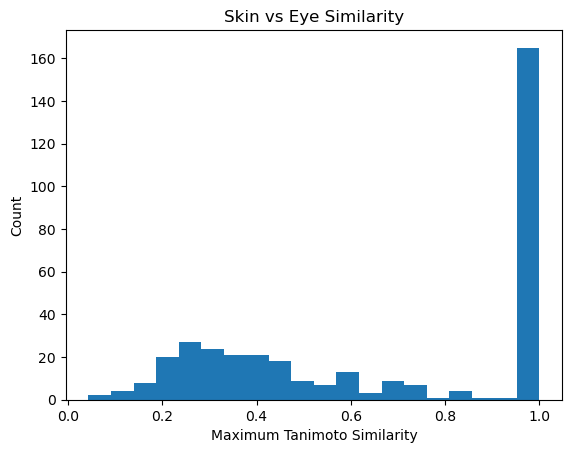

In [74]:
plt.hist(max_sims, bins=20)

plt.xlabel("Maximum Tanimoto Similarity")
plt.ylabel("Count")
plt.title("Skin vs Eye Similarity")

plt.show()

그래프를 보면 크게 두 집단으로 나누어 볼 수 있다. 0.15~0.60 부근에 있는 집단과 0.95~1.00 부근에 높은 수치로 몰려있는 집단이 있다. 0.15~0.60 부근에 있는 집단은 Eye 데이터셋에 어느 정도 비슷한 구조는 있지만 동일하지는 않은 화합물들이고 0.95~1.00 부근에 있는 집단은 동일 화합물이거나 매우 유사한 화합물들이 양쪽 데이터셋에 공통으로 존재한다는 뜻이다. 

PCA 결과와 비교해봤을 때 PCA 그래프에서도 완전히 분리된 형태가 아니라 상당 부분 겹쳤었고 공통 Scaffold가 존재하는 것, Tanimoto 실험에서 평균 0.67 이라는 수치가 나온 것과 1.0 근처 화합물이 다수였다는 것을 종합해보면 Skin Irritation - Corrosion과 Eye Irritaion 데이터셋은 상당한 구조적 유사성을 공유하고 있지만 일부 화합물은 낮은 Tanimoto Similarity를 보여 독립적인 chemical space 역시 존재함을 알 수 있었다. 

아래의 두 셀(# 1, 2 셀)을 통해 약 166개의 Skin 화합물은 Eye 데이터셋에서 거의 동일한 구조를 갖는 화합물을 찾을 수 있었다. 


In [77]:
#1
sum(np.array(max_sims) == 1.0)

np.int64(165)

In [78]:
#2
sum(np.array(max_sims) >= 0.9)

np.int64(166)

<Figure size 600x500 with 0 Axes>

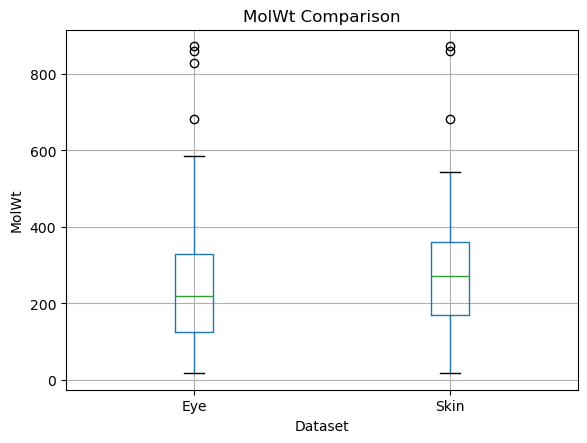

<Figure size 600x500 with 0 Axes>

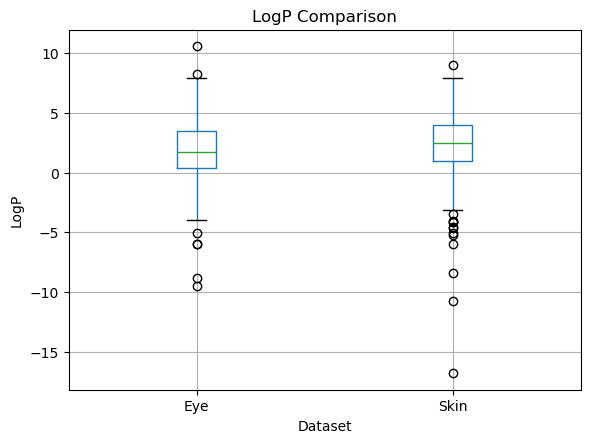

<Figure size 600x500 with 0 Axes>

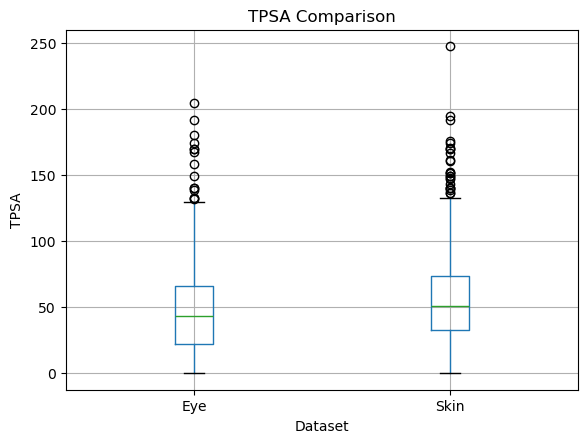

<Figure size 600x500 with 0 Axes>

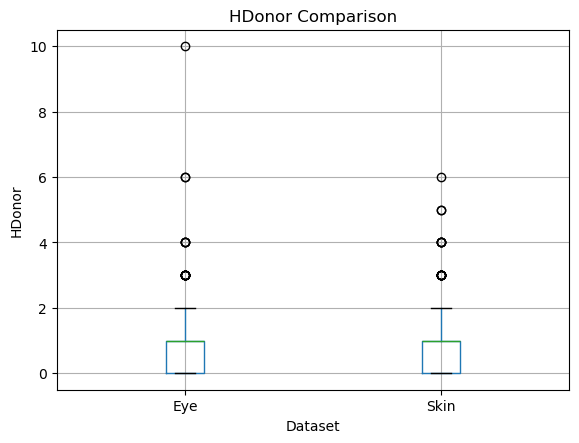

<Figure size 600x500 with 0 Axes>

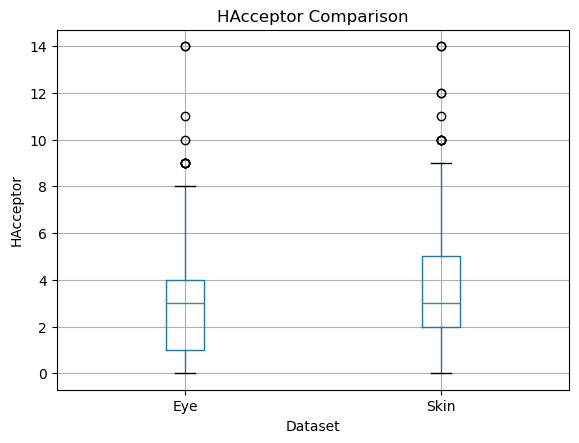

<Figure size 600x500 with 0 Axes>

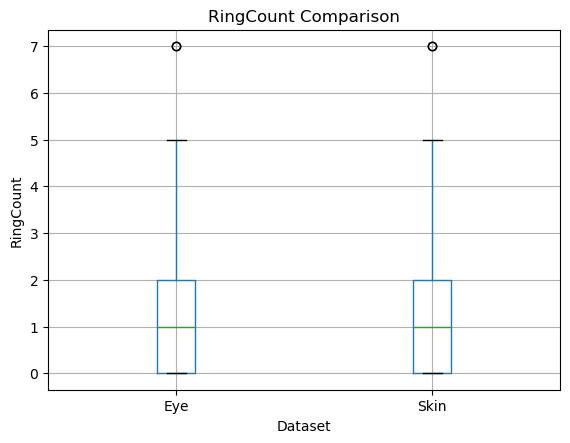


====== MolWt ======
Skin
count    365.000000
mean     270.399005
std      128.439780
min       18.015000
25%      170.595000
50%      270.457000
75%      359.325000
max      873.090000
Name: MolWt, dtype: float64

Eye
count    302.000000
mean     239.111179
std      141.968881
min       17.031000
25%      125.954250
50%      220.616500
75%      329.762500
max      873.090000
Name: MolWt, dtype: float64

====== LogP ======
Skin
count    365.000000
mean       2.201742
std        2.747877
min      -16.825800
25%        0.982900
50%        2.503700
75%        3.937900
max        8.994300
Name: LogP, dtype: float64

Eye
count    302.000000
mean       1.845903
std        2.558482
min       -9.505800
25%        0.391800
50%        1.710090
75%        3.503850
max       10.589800
Name: LogP, dtype: float64

====== TPSA ======
Skin
count    365.000000
mean      57.877726
std       39.251053
min        0.000000
25%       32.460000
50%       50.690000
75%       73.590000
max      247.760000
Name

In [85]:
# Boxplot 비교 
# Skin과 Eye 의 Descriptor 자체를 직접 비교하는 그래프 


import pandas as pd 
import matplotlib.pyplot as plt 

desc_cols = [
    "MolWt", "LogP", "TPSA",
    "HDonor", "HAcceptor", "RingCount"
]

for col in desc_cols:

    plot_df = pd.concat([
        pd.DataFrame({
            "Dataset" : "Skin", 
            "value" : skin_final[col]
        }), 
        pd.DataFrame({
            "Dataset": "Eye",
            "value": eye_final[col] 
        })
    ])

    plt.figure(figsize=(6, 5))

    plot_df.boxplot(
        column = "value", 
        by = "Dataset"
    )

    plt.title(f"{col} Comparison")
    plt.suptitle("")
    plt.ylabel(col)

    plt.show()


for col in desc_cols:
    print(f"\n====== {col} ======")
    print("Skin")
    print(skin_final[col].describe())

    print("\nEye")
    print(eye_final[col].describe())


[MolWt]

Skin median = 270.5 / Eye median = 220.6

- 그래프를 봤을 때 Skin 박스가 전체적으로 위에 있음 
- Skin Irritation - Corrosioin 데이터셋의 화합물은 Eye irritation 데이터셋보다 분자량이 큰 경향을 보였다. 


[TPSA]

Skin median > Eye median

- Skin 데이터셋은 더 큰 polar surface area(TPSA)를 갖는 화합물을 포함하는 경향을 보였다. 


[HAcceptor]

Eye median ≈ 3
Skin median ≈ 3

- Skin 쪽 분포가 더 넓음
- 두 데이터셋의 H-bond acceptor 수는 유사하지만, Skin 데이터셋에서 더 다양한 범위가 관찰되었다. 



[LogP]

- H-bond donor 수으 분포는 두 데이터셋에서 큰 차이를 보이지 않았다. 



[RingCount]

- Ring Count 분포 역시 매우 유사하였다. 